In [1]:
import fastf1
print(fastf1.__version__)


3.8.3


In [21]:
import os

# Crear la carpeta de caché si no existe (exist_ok=True evita error si ya existe)
os.makedirs('../cache', exist_ok=True)
print('Caché en:', os.path.abspath('../cache'))

fastf1.Cache.enable_cache('../cache')

session = fastf1.get_session(2024, 'Monza', 'R')
session.load()

Caché en: /Users/alvaroruiz/Desktop/proyecto f1/cache


core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


In [22]:
os.getcwd()

'/Users/alvaroruiz/Desktop/proyecto f1/f1-strategy-analytics'

In [23]:
os.makedirs('cache', exist_ok=True)
...
fastf1.Cache.enable_cache('cache')

In [24]:
session.results[['Abbreviation', 'TeamName', 'GridPosition', 'Position', 'Points', 'Status']]

,Abbreviation,TeamName,GridPosition,Position,Points,Status
16,LEC,Ferrari,4.0,1.0,25.0,Finished
81,PIA,McLaren,2.0,2.0,18.0,Finished
4,NOR,McLaren,1.0,3.0,16.0,Finished
55,SAI,Ferrari,5.0,4.0,12.0,Finished
44,HAM,Mercedes,6.0,5.0,10.0,Finished
1,VER,Red Bull Racing,7.0,6.0,8.0,Finished
63,RUS,Mercedes,3.0,7.0,6.0,Finished
11,PER,Red Bull Racing,8.0,8.0,4.0,Finished
23,ALB,Williams,9.0,9.0,2.0,Finished
20,MAG,Haas F1 Team,13.0,10.0,1.0,Finished


In [25]:
# Copiamos las columnas que nos interesan
res = session.results[['Abbreviation', 'TeamName', 'GridPosition', 'Position']].copy()

# Posiciones ganadas = salida - llegada (positivo = remontó, negativo = perdió)
res['Ganadas'] = res['GridPosition'] - res['Position']

# Ordenamos de mayor remontada a mayor caída
res.sort_values('Ganadas', ascending=False)

,Abbreviation,TeamName,GridPosition,Position,Ganadas
43,COL,Williams,18.0,12.0,6.0
16,LEC,Ferrari,4.0,1.0,3.0
77,BOT,Kick Sauber,19.0,16.0,3.0
20,MAG,Haas F1 Team,13.0,10.0,3.0
24,ZHO,Kick Sauber,20.0,18.0,2.0
55,SAI,Ferrari,5.0,4.0,1.0
44,HAM,Mercedes,6.0,5.0,1.0
1,VER,Red Bull Racing,7.0,6.0,1.0
31,OCO,Alpine,15.0,14.0,1.0
81,PIA,McLaren,2.0,2.0,0.0


In [26]:
laps = session.laps
laps.shape

(1008, 31)

In [27]:
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:18.931000,LEC,16,0 days 00:01:28.179000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:29.989000,...,True,Ferrari,0 days 00:55:50.494000,2024-09-01 13:03:34.413,1,2.0,False,,False,False
1,0 days 00:58:44.327000,LEC,16,0 days 00:01:25.396000,2.0,1.0,NaT,NaT,0 days 00:00:27.707000,0 days 00:00:29.265000,...,True,Ferrari,0 days 00:57:18.931000,2024-09-01 13:05:02.850,1,2.0,False,,False,True
2,0 days 01:00:09.506000,LEC,16,0 days 00:01:25.179000,3.0,1.0,NaT,NaT,0 days 00:00:27.679000,0 days 00:00:29.001000,...,True,Ferrari,0 days 00:58:44.327000,2024-09-01 13:06:28.246,1,2.0,False,,False,True
3,0 days 01:01:34.316000,LEC,16,0 days 00:01:24.810000,4.0,1.0,NaT,NaT,0 days 00:00:27.653000,0 days 00:00:28.883000,...,True,Ferrari,0 days 01:00:09.506000,2024-09-01 13:07:53.425,1,2.0,False,,False,True
4,0 days 01:02:58.919000,LEC,16,0 days 00:01:24.603000,5.0,1.0,NaT,NaT,0 days 00:00:27.630000,0 days 00:00:28.790000,...,True,Ferrari,0 days 01:01:34.316000,2024-09-01 13:09:18.235,1,2.0,False,,False,True


In [28]:
laps.columns.tolist()

['Time',
 'Driver',
 'DriverNumber',
 'LapTime',
 'LapNumber',
 'Stint',
 'PitOutTime',
 'PitInTime',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'Sector1SessionTime',
 'Sector2SessionTime',
 'Sector3SessionTime',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'IsPersonalBest',
 'Compound',
 'TyreLife',
 'FreshTyre',
 'Team',
 'LapStartTime',
 'LapStartDate',
 'TrackStatus',
 'Position',
 'Deleted',
 'DeletedReason',
 'FastF1Generated',
 'IsAccurate']

## Guía de columnas: `session.laps`

| Columna | Qué significa |
|---|---|
| `Driver`, `Team` | Piloto (abreviatura) y equipo |
| `LapNumber` | Número de vuelta |
| `LapTime` | Tiempo de la vuelta (timedelta, pasar a segundos) |
| `Sector1Time`–`Sector3Time` | Tiempo de cada uno de los 3 sectores |
| `Stint` | Tramo de carrera entre paradas (1 = primer juego de neumáticos) |
| `Compound` | Compuesto del neumático: SOFT, MEDIUM, HARD, INTERMEDIATE, WET |
| `TyreLife` | Vueltas que lleva ese neumático |
| `FreshTyre` | Si el neumático era nuevo al montarlo |
| `PitInTime`, `PitOutTime` | Momento de entrada y salida de boxes (vacío si no paró) |
| `SpeedI1`, `SpeedI2`, `SpeedFL`, `SpeedST` | Velocidad en 2 puntos intermedios, meta y trampa de velocidad (km/h) |
| `TrackStatus` | Estado de pista: 1 = verde, 2 = amarilla, 4 = safety car, 5 = roja, 6/7 = VSC |
| `Position` | Posición al final de la vuelta |
| `Deleted` | Vuelta anulada (por ejemplo, por límites de pista) |
| `IsAccurate` | Si FastF1 considera fiable el tiempo |

### Observaciones
- La vuelta 1 no es representativa: salida parada, sin `Sector1Time` e `IsAccurate = False`.
- Los tiempos bajan durante el stint por el efecto del combustible.

# Entender las vueltas

In [29]:
# Trabajamos sobre una copia para no modificar los datos originales
laps = session.laps.copy()

# .dt.total_seconds() convierte un timedelta en segundos (1:28.179 → 88.179)
laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()

laps[['Driver', 'LapNumber', 'LapTime', 'LapTimeSec', 'Compound']].head(10)

,Driver,LapNumber,LapTime,LapTimeSec,Compound
0,LEC,1.0,0 days 00:01:28.179000,88.179,MEDIUM
1,LEC,2.0,0 days 00:01:25.396000,85.396,MEDIUM
2,LEC,3.0,0 days 00:01:25.179000,85.179,MEDIUM
3,LEC,4.0,0 days 00:01:24.810000,84.810,MEDIUM
4,LEC,5.0,0 days 00:01:24.603000,84.603,MEDIUM
5,LEC,6.0,0 days 00:01:24.663000,84.663,MEDIUM
6,LEC,7.0,0 days 00:01:24.434000,84.434,MEDIUM
7,LEC,8.0,0 days 00:01:24.569000,84.569,MEDIUM
8,LEC,9.0,0 days 00:01:24.362000,84.362,MEDIUM
9,LEC,10.0,0 days 00:01:24.432000,84.432,MEDIUM


In [30]:
# Agrupar por piloto y compuesto, contar vueltas y poner los compuestos como columnas
vueltas_por_compuesto = laps.groupby(['Driver', 'Compound']).size().unstack(fill_value=0)
vueltas_por_compuesto

Compound,HARD,MEDIUM,SOFT
Driver,,,
ALB,36,17,0
ALO,41,12,0
BOT,33,19,0
COL,37,16,0
GAS,42,10,0
HAM,38,15,0
HUL,47,5,0
LEC,38,15,0
MAG,39,14,0


In [31]:
# El número máximo de stint = número de paradas + 1
paradas = laps.groupby('Driver')['Stint'].max() - 1
paradas.sort_values()

Driver
TSU    0.0
ALB    1.0
SAI    1.0
RIC    1.0
OCO    1.0
MAG    1.0
LEC    1.0
ZHO    1.0
COL    1.0
BOT    1.0
HAM    2.0
VER    2.0
GAS    2.0
PER    2.0
PIA    2.0
RUS    2.0
ALO    2.0
HUL    2.0
NOR    2.0
STR    3.0
Name: Stint, dtype: float64

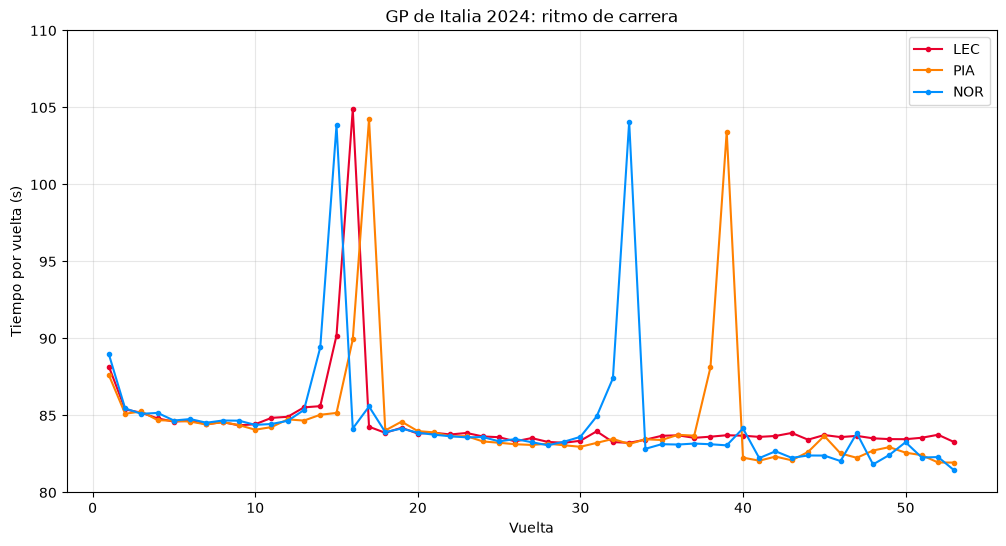

In [35]:
import matplotlib.pyplot as plt

# Diccionario: a cada piloto le asignamos un color (código hexadecimal)
colores = {
    'LEC': '#E8002D',   # Ferrari: rojo
    'PIA': '#FF8000',   # McLaren: naranja papaya
    'NOR': '#0090FF',   # McLaren: azul, para distinguirlo de su compañero
}

fig, ax = plt.subplots(figsize=(12, 6))

for piloto, color in colores.items():
    datos = laps[laps['Driver'] == piloto]
    ax.plot(datos['LapNumber'], datos['LapTimeSec'],
            color=color, marker='o', markersize=3, label=piloto)

ax.set_xlabel('Vuelta')
ax.set_ylabel('Tiempo por vuelta (s)')
ax.set_title('GP de Italia 2024: ritmo de carrera')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(80, 110)   # solo mostramos tiempos entre 81 y 88 segundos
plt.show()

# temporada completa


In [1]:
import pandas as pd

vueltas = pd.read_parquet('data/raw/laps_2024.parquet')
resultados = pd.read_parquet('data/raw/results_2024.parquet')

print('Vueltas:', vueltas.shape)
print('Resultados:', resultados.shape)

# ¿Cuántos pilotos hay en cada carrera? Ordenamos de menos a más
resultados.groupby('Event').size().sort_values().head()

Vueltas: (26604, 34)
Resultados: (479, 25)


Event
Australian Grand Prix       19
Abu Dhabi Grand Prix        20
Spanish Grand Prix          20
Singapore Grand Prix        20
Saudi Arabian Grand Prix    20
dtype: int64

**Nota:** Australia 2024 tiene 19 resultados porque Sargeant no corrió: Williams dio su coche a Albon tras el accidente de este en los libres 1. No es un error de datos.


# limpieza


In [3]:
limpias = pd.read_parquet('data/processed/laps_clean_2024.parquet')

resumen = pd.DataFrame({
    'brutas': vueltas.groupby('Event').size(),
    'limpias': limpias.groupby('Event').size(),
})
resumen['% conservado'] = (resumen['limpias'] / resumen['brutas'] * 100).round(1)
resumen.sort_values('% conservado')

,brutas,limpias,% conservado
Event,,,
Canadian Grand Prix,1272,176,13.8
Monaco Grand Prix,1237,557,45.0
British Grand Prix,960,553,57.6
São Paulo Grand Prix,1134,687,60.6
Qatar Grand Prix,943,631,66.9
Chinese Grand Prix,1032,744,72.1
Japanese Grand Prix,907,725,79.9
Hungarian Grand Prix,1355,1103,81.4
Mexico City Grand Prix,1215,992,81.6


In [5]:
import importlib
import src.clean as clean
importlib.reload(clean)   # recarga clean.py por si lo has cambiado

canada = vueltas[vueltas['Event'] == 'Canadian Grand Prix']
_ = clean.limpiar_vueltas(canada)

Sin tiempo registrado                      -     5 vueltas
Primera vuelta                             -    20 vueltas
Entrada/salida de boxes                    -    84 vueltas
Pista no verde (SC, VSC, banderas)         -   249 vueltas
Vuelta anulada                             -     0 vueltas
Poco fiable (IsAccurate)                   -     0 vueltas
> 107 % de la mediana (carrera y compuesto) -    95 vueltas

Total: 1272 -> 819 vueltas (64.4% conservadas)


# Documentar la decisión

### Decisión de limpieza: filtro del 107 %

**Problema:** comparar cada vuelta con la más rápida de la carrera eliminaba la mayoría de vueltas de carreras con lluvia (Canadá: solo se conservaba el 13,8 %) o con gestión extrema de neumáticos (Mónaco), porque se comparaban vueltas en mojado o en modo ahorro con una vuelta rápida en seco y con neumático nuevo.

**Solución:** comparar con la **mediana** de la carrera para el **mismo compuesto**. Así solo se eliminan las vueltas anómalas de verdad.

**Resultado:** Canadá pasa de conservar el 13,8 % de las vueltas al 64,4 %.

**Limitaciones conocidas:**
- La columna `Deleted` está vacía porque se descargó con `messages=False`, así que no se filtran vueltas anuladas por límites de pista.
- En Silverstone, todas las vueltas de Gasly están marcadas como poco fiables por FastF1.

# DuckDB y SQL

In [9]:
import duckdb

# read_only=True: solo leemos, así no bloqueamos el archivo para los scripts
con = duckdb.connect('data/f1.duckdb', read_only=True)

# Comprobar qué tablas hay
con.sql("SHOW TABLES").df()



,name
0,laps
1,results


ganador de cada carrera

In [11]:
con.sql("""
    SELECT Round, Event, Abbreviation AS ganador, TeamName AS equipo
    FROM results
    WHERE Position = 1
    ORDER BY Round
""").df()

,Round,Event,ganador,equipo
0,1,Bahrain Grand Prix,VER,Red Bull Racing
1,2,Saudi Arabian Grand Prix,VER,Red Bull Racing
2,3,Australian Grand Prix,SAI,Ferrari
3,4,Japanese Grand Prix,VER,Red Bull Racing
4,5,Chinese Grand Prix,VER,Red Bull Racing
5,6,Miami Grand Prix,NOR,McLaren
6,7,Emilia Romagna Grand Prix,VER,Red Bull Racing
7,8,Monaco Grand Prix,LEC,Ferrari
8,9,Canadian Grand Prix,VER,Red Bull Racing
9,10,Spanish Grand Prix,VER,Red Bull Racing


puntos, podios y victorias por piloto

In [12]:
con.sql("""
    SELECT Abbreviation AS piloto,
           SUM(Points) AS puntos,
           COUNT(*) FILTER (WHERE Position <= 3) AS podios,
           COUNT(*) FILTER (WHERE Position = 1) AS victorias
    FROM results
    GROUP BY Abbreviation
    ORDER BY puntos DESC
""").df()

,piloto,puntos,podios,victorias
0,VER,399.0,14,9
1,NOR,344.0,13,4
2,LEC,327.0,13,3
3,PIA,265.0,8,2
4,SAI,262.0,9,2
5,RUS,226.0,4,2
6,HAM,207.0,5,2
7,PER,138.0,4,0
8,ALO,70.0,0,0
9,GAS,40.0,1,0


vuelta limpia más rápida de cada carrera

In [13]:
con.sql("""
    SELECT Round, Event,
           arg_min(Driver, LapTimeSec) AS piloto,
           ROUND(MIN(LapTimeSec), 3) AS mejor_vuelta_s
    FROM laps
    GROUP BY Round, Event
    ORDER BY Round
""").df()

,Round,Event,piloto,mejor_vuelta_s
0,1,Bahrain Grand Prix,VER,92.608
1,2,Saudi Arabian Grand Prix,LEC,91.632
2,3,Australian Grand Prix,LEC,79.813
3,4,Japanese Grand Prix,VER,93.706
4,5,Chinese Grand Prix,ALO,97.810
5,6,Miami Grand Prix,PIA,90.634
6,7,Emilia Romagna Grand Prix,RUS,78.589
7,8,Monaco Grand Prix,HAM,74.165
8,9,Canadian Grand Prix,HAM,74.856
9,10,Spanish Grand Prix,NOR,77.115


número medio de paradas por carrera

In [14]:
con.sql("""
    SELECT Event, ROUND(AVG(paradas), 2) AS paradas_medias
    FROM (
        SELECT Event, Driver, MAX(Stint) - 1 AS paradas
        FROM laps
        GROUP BY Event, Driver
    )
    GROUP BY Event
    ORDER BY paradas_medias DESC
""").df()

,Event,paradas_medias
0,Qatar Grand Prix,3.06
1,Japanese Grand Prix,2.94
2,British Grand Prix,2.37
3,Austrian Grand Prix,2.25
4,Bahrain Grand Prix,2.15
5,Canadian Grand Prix,2.10
6,Spanish Grand Prix,2.10
7,Hungarian Grand Prix,2.00
8,Chinese Grand Prix,1.95
9,Las Vegas Grand Prix,1.90


ritmo medio por equipo (la versión con trampa)

In [15]:
con.sql("""
    SELECT Team AS equipo,
           ROUND(AVG(LapTimeSec), 3) AS ritmo_medio_s,
           COUNT(*) AS vueltas
    FROM laps
    GROUP BY Team
    ORDER BY ritmo_medio_s
""").df()

,equipo,ritmo_medio_s,vueltas
0,McLaren,88.040,2486
1,Mercedes,88.094,2371
2,Ferrari,88.327,2436
3,Red Bull Racing,88.651,2283
4,RB,88.886,2222
5,Kick Sauber,89.089,2292
6,Aston Martin,89.252,2262
7,Alpine,89.346,2178
8,Williams,89.623,2000
9,Haas F1 Team,89.841,2274


ritmo por equipo (la versión justa)

In [16]:
con.sql("""
    WITH ritmo AS (
        SELECT Round, Team, MEDIAN(LapTimeSec) AS ritmo_equipo
        FROM laps
        GROUP BY Round, Team
    ),
    gaps AS (
        SELECT Team,
               (ritmo_equipo / MIN(ritmo_equipo) OVER (PARTITION BY Round) - 1) * 100 AS gap_pct
        FROM ritmo
    )
    SELECT Team AS equipo,
           ROUND(AVG(gap_pct), 2) AS gap_medio_pct,
           COUNT(*) AS carreras
    FROM gaps
    GROUP BY Team
    ORDER BY gap_medio_pct
""").df()

,equipo,gap_medio_pct,carreras
0,McLaren,0.26,24
1,Red Bull Racing,0.39,24
2,Ferrari,0.43,24
3,Mercedes,0.54,24
4,Aston Martin,1.43,24
5,Haas F1 Team,1.55,23
6,RB,1.79,24
7,Alpine,1.82,24
8,Williams,2.01,24
9,Kick Sauber,2.14,24


In [2]:
import pandas as pd

for tabla in ['laps', 'results', 'weather', 'track_status', 'race_control', 'pit_stops']:
    df = pd.read_parquet(f'data/raw/{tabla}_2024.parquet')
    print(f'{tabla:<14} {len(df):>7} filas')

laps             26604 filas
results            479 filas
weather           3690 filas
track_status       220 filas
race_control      2131 filas
pit_stops          849 filas


In [3]:
import duckdb
from IPython.display import display

con = duckdb.connect('data/f1.duckdb', read_only=True)

consultas = {
    '7. Minutos de safety car, VSC y banderas rojas por carrera': r"""
        SELECT Round, Event,
               ROUND(SUM(DuracionSec) FILTER (WHERE Status = '4') / 60, 1) AS min_safety_car,
               ROUND(SUM(DuracionSec) FILTER (WHERE Status IN ('6', '7')) / 60, 1) AS min_vsc,
               COUNT(*) FILTER (WHERE Status = '5') AS banderas_rojas
        FROM track_status
        GROUP BY Round, Event
        ORDER BY Round
    """,
    '8. Sanciones de tiempo por piloto': r"""
        SELECT regexp_extract(Message, '\((\w{3})\)', 1) AS piloto,
               COUNT(*) AS sanciones
        FROM race_control
        WHERE Message LIKE '%TIME PENALTY%'
        GROUP BY piloto
        ORDER BY sanciones DESC
    """,
    '9. Lluvia y temperatura de pista por carrera': r"""
        SELECT Round, Event,
               ROUND(100 * AVG(CAST(Rainfall AS INTEGER)), 1) AS pct_tiempo_lloviendo,
               ROUND(AVG(TrackTemp), 1) AS temp_pista_media
        FROM weather
        GROUP BY Round, Event
        ORDER BY pct_tiempo_lloviendo DESC
    """,
    '10. Tiempo en el pit lane por equipo': r"""
        SELECT Team AS equipo,
               ROUND(MEDIAN(TiempoPitLaneSec), 2) AS pit_lane_mediana_s,
               COUNT(*) AS paradas
        FROM pit_stops
        WHERE TiempoPitLaneSec BETWEEN 10 AND 60
        GROUP BY Team
        ORDER BY pit_lane_mediana_s
    """,
}

for titulo, sql in consultas.items():
    print(f'\n=== {titulo} ===')
    display(con.sql(sql).df())

con.close()


=== 7. Minutos de safety car, VSC y banderas rojas por carrera ===


,Round,Event,min_safety_car,min_vsc,banderas_rojas
0,1,Bahrain Grand Prix,NaN,NaN,0
1,2,Saudi Arabian Grand Prix,6.8,NaN,0
2,3,Australian Grand Prix,NaN,1.3,0
3,4,Japanese Grand Prix,NaN,NaN,1
4,5,Chinese Grand Prix,17.5,4.1,0
5,6,Miami Grand Prix,8.9,0.9,0
6,7,Emilia Romagna Grand Prix,NaN,NaN,0
7,8,Monaco Grand Prix,1.8,NaN,1
8,9,Canadian Grand Prix,17.8,NaN,0
9,10,Spanish Grand Prix,NaN,NaN,0



=== 8. Sanciones de tiempo por piloto ===


,piloto,sanciones
0,MAG,8
1,RIC,5
2,STR,5
3,VER,4
4,PIA,3
5,PER,3
6,NOR,2
7,GAS,2
8,HAM,2
9,RUS,2



=== 9. Lluvia y temperatura de pista por carrera ===


,Round,Event,pct_tiempo_lloviendo,temp_pista_media
0,21,São Paulo Grand Prix,58.2,25.8
1,12,British Grand Prix,34.7,27.7
2,9,Canadian Grand Prix,27.4,24.6
3,11,Austrian Grand Prix,0.7,46.4
4,10,Spanish Grand Prix,0.6,41.1
5,6,Miami Grand Prix,0.0,44.7
6,7,Emilia Romagna Grand Prix,0.0,42.0
7,16,Italian Grand Prix,0.0,49.3
8,20,Mexico City Grand Prix,0.0,35.6
9,5,Chinese Grand Prix,0.0,29.8



=== 10. Tiempo en el pit lane por equipo ===


,equipo,pit_lane_mediana_s,paradas
0,McLaren,22.89,77
1,Mercedes,22.91,78
2,Red Bull Racing,22.93,80
3,RB,22.94,72
4,Ferrari,23.09,75
5,Alpine,23.21,71
6,Aston Martin,23.27,81
7,Williams,23.55,72
8,Haas F1 Team,24.01,85
9,Kick Sauber,24.26,78


# meteorología por vuelta

In [11]:
limpias = pd.read_parquet('data/processed/laps_clean_2024.parquet')

# Vueltas en mojado por carrera (solo las que tuvieron lluvia)
lluvia = (limpias.groupby('Event')['Lluvia']
          .agg(vueltas_mojado='sum', pct_mojado='mean')
          .query('vueltas_mojado > 0')
          .sort_values('pct_mojado', ascending=False))
lluvia['pct_mojado'] = (lluvia['pct_mojado'] * 100).round(1)
lluvia

,vueltas_mojado,pct_mojado
Event,,
São Paulo Grand Prix,491,64.8
British Grand Prix,294,36.3
Canadian Grand Prix,206,25.7
Spanish Grand Prix,20,1.7


# Posiciones y diferencias a lo largo de la carrera

In [12]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('cache')
session = fastf1.get_session(2024, 'Canada', 'R')
session.load(telemetry=False, weather=False, messages=False)
laps = session.laps

# Vueltas con safety car (4) o VSC (6, 7) en algún momento
neutralizada = laps.groupby('LapNumber')['TrackStatus'].agg(
    lambda s: s.astype(str).str.contains('4|6|7').any()
)
vueltas_sc = neutralizada[neutralizada].index.tolist()
print('Vueltas neutralizadas:', vueltas_sc)

def sombrear_sc(ax):
    """Sombrea en amarillo las vueltas con safety car o VSC."""
    for v in vueltas_sc:
        ax.axvspan(v - 1, v, color='gold', alpha=0.25, lw=0)

core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '63', '44', '81', '14', '18', '3', '10', '31', '27', '20', '77', '22', '24', '55', '23', '11', '16', '2']


Vueltas neutralizadas: [24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0]


req            INFO 	Using cached data for driver_info


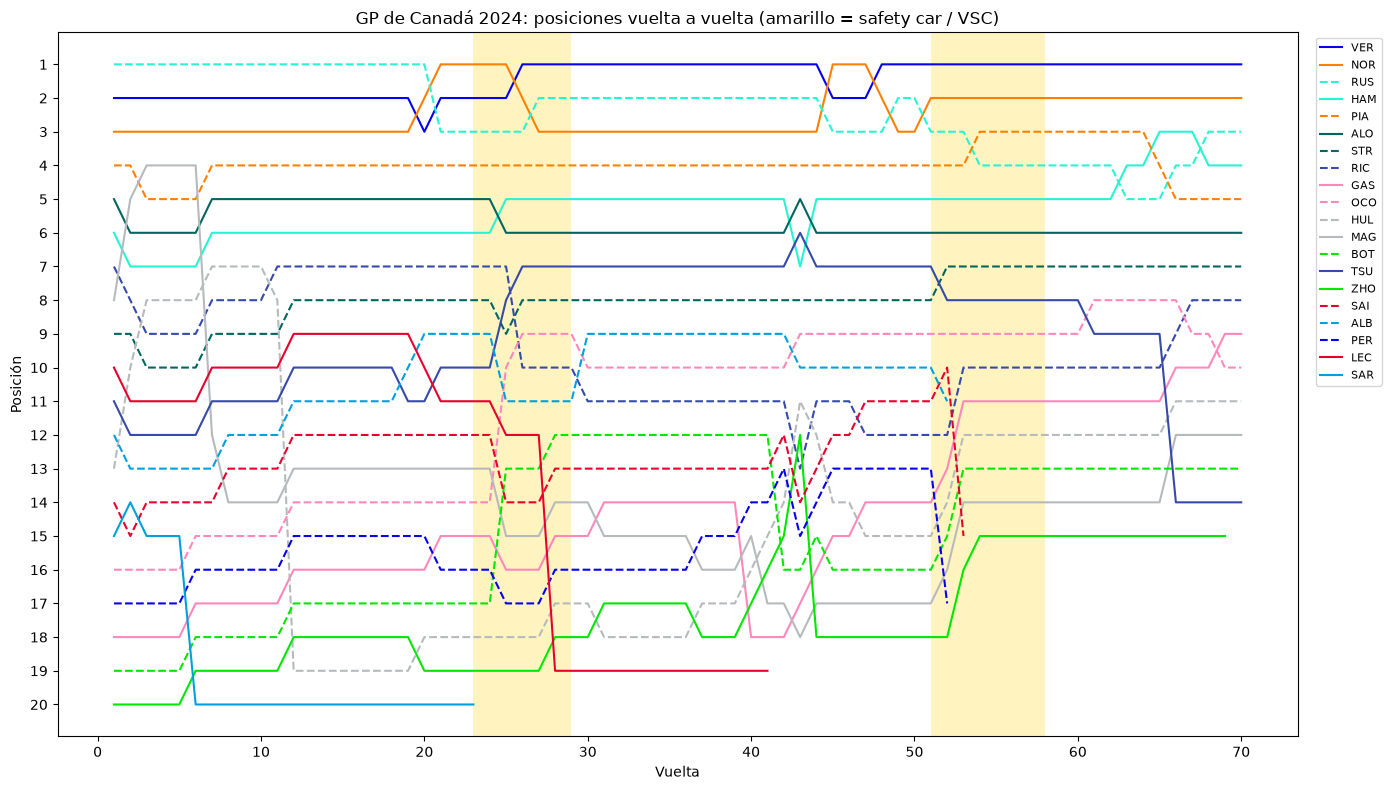

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

for num in session.drivers:
    piloto = session.get_driver(num)['Abbreviation']
    datos = laps.pick_drivers(piloto)
    # Color del equipo + tipo de línea distinto para cada compañero
    estilo = fastf1.plotting.get_driver_style(
        identifier=piloto, style=['color', 'linestyle'], session=session
    )
    ax.plot(datos['LapNumber'], datos['Position'], label=piloto, **estilo)

sombrear_sc(ax)
ax.invert_yaxis()                  # el 1º arriba
ax.set_yticks(range(1, 21))
ax.set_xlabel('Vuelta')
ax.set_ylabel('Posición')
ax.set_title('GP de Canadá 2024: posiciones vuelta a vuelta (amarillo = safety car / VSC)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


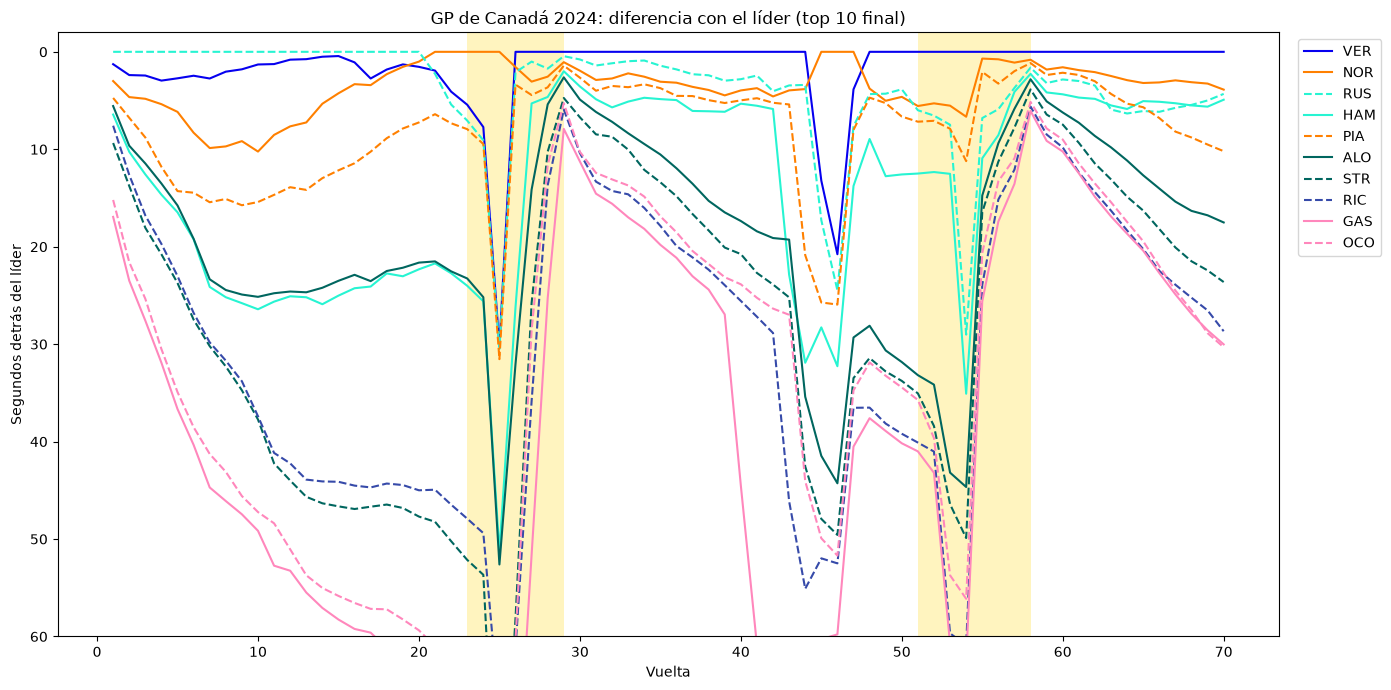

In [14]:
gaps = laps.copy()
gaps['TimeSec'] = gaps['Time'].dt.total_seconds()

# El líder es quien completa cada vuelta antes: el menor 'Time' de esa vuelta
gaps['TiempoLider'] = gaps.groupby('LapNumber')['TimeSec'].transform('min')
gaps['GapLider'] = gaps['TimeSec'] - gaps['TiempoLider']

top10 = session.results['Abbreviation'].head(10).tolist()

fig, ax = plt.subplots(figsize=(14, 7))
for piloto in top10:
    datos = gaps[gaps['Driver'] == piloto]
    estilo = fastf1.plotting.get_driver_style(
        identifier=piloto, style=['color', 'linestyle'], session=session
    )
    ax.plot(datos['LapNumber'], datos['GapLider'], label=piloto, **estilo)

sombrear_sc(ax)
ax.set_ylim(60, -2)                # 0 arriba = líder; limitamos a 60 s para ver bien el grupo
ax.set_xlabel('Vuelta')
ax.set_ylabel('Segundos detrás del líder')
ax.set_title('GP de Canadá 2024: diferencia con el líder (top 10 final)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()